# Task 1: Transmission Curves → Bubble Size Recovery

Visualize how well the trained 1-D CNN recovers the local ionized bubble depth from Lyman-alpha transmission spectra.

**Figures:**
1. True vs. predicted bubble depth — histogram overlay (all redshifts combined)
2. True vs. predicted — scatter plot
3. Residuals vs. true depth
4. CDF comparison (KS test)
5. Per-redshift: true vs. predicted distribution (one panel per z)

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, pearsonr, spearmanr

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'task1_transmission_to_bubble_size'

d = np.load(RESULTS_DIR / 'test_predictions.npz')
y_true    = d['y_true']    # Mpc/h
y_pred    = d['y_pred']    # Mpc/h
redshifts = d['redshift']  # per-sample redshift

print(f'Test samples : {len(y_true)}')
print(f'Redshifts    : {np.unique(redshifts)}')
print(f'y_true  — min={y_true.min():.3f}  median={np.median(y_true):.3f}  max={y_true.max():.3f}  Mpc/h')
print(f'y_pred  — min={y_pred.min():.3f}  median={np.median(y_pred):.3f}  max={y_pred.max():.3f}  Mpc/h')

Test samples : 2000
Redshifts    : [7.4985]
y_true  — min=1.000  median=3.800  max=25.860  Mpc/h
y_pred  — min=1.909  median=4.200  max=15.817  Mpc/h


In [2]:
rmse     = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
r2       = float(1 - np.var(y_pred - y_true) / np.var(y_true))
rho_p    = float(pearsonr(y_true, y_pred)[0])
rho_s    = float(spearmanr(y_true, y_pred)[0])
ks, ks_p = ks_2samp(y_true, y_pred)

print(f'RMSE         = {rmse:.4f} Mpc/h')
print(f'R²           = {r2:.4f}')
print(f'Pearson r    = {rho_p:.4f}')
print(f'Spearman ρ   = {rho_s:.4f}')
print(f'KS statistic = {ks:.4f}  (p={ks_p:.3g})')

RMSE         = 6.8910 Mpc/h
R²           = -0.0002
Pearson r    = 0.0426
Spearman ρ   = 0.0413
KS statistic = 0.4650  (p=1.29e-195)


## 1. Distribution — true vs. predicted (all redshifts)

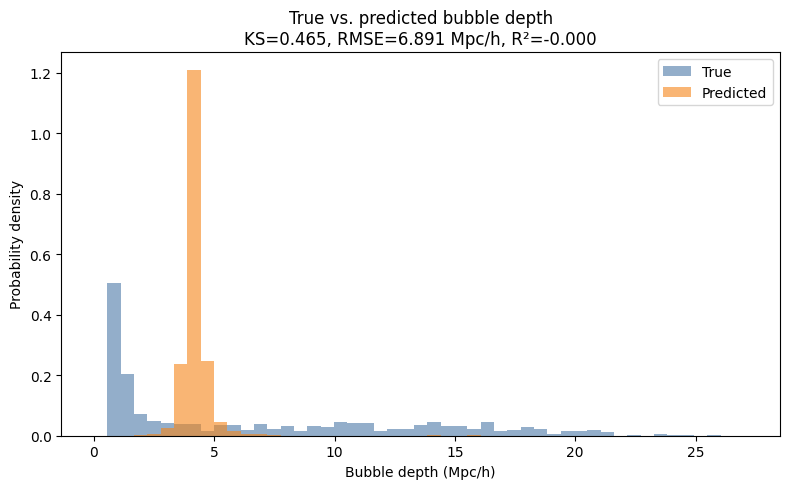

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, max(y_true.max(), y_pred.max()) * 1.05, 50)
ax.hist(y_true, bins=bins, density=True, alpha=0.6, color='#4C78A8', label='True')
ax.hist(y_pred, bins=bins, density=True, alpha=0.6, color='#F58518', label='Predicted')
ax.set_xlabel('Bubble depth (Mpc/h)')
ax.set_ylabel('Probability density')
ax.set_title(f'True vs. predicted bubble depth\nKS={ks:.3f}, RMSE={rmse:.3f} Mpc/h, R²={r2:.3f}')
ax.legend()
fig.tight_layout()
plt.show()

## 2. Scatter plot — true vs. predicted

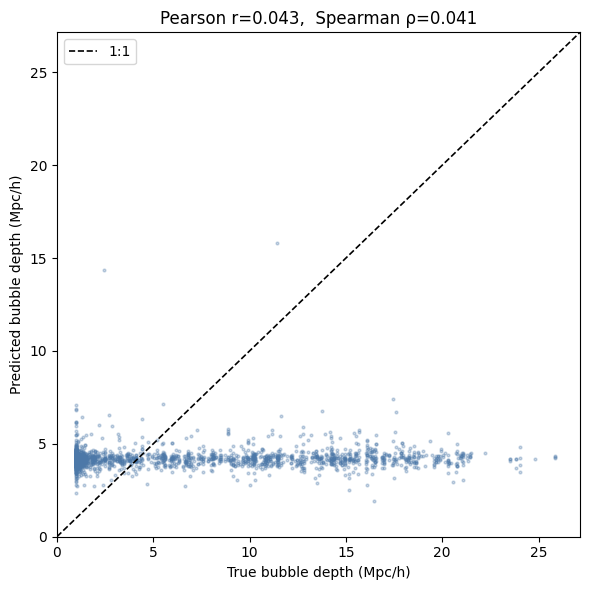

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, s=4, alpha=0.3, color='#4C78A8', rasterized=True)
lim = max(y_true.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='1:1')
ax.set_xlabel('True bubble depth (Mpc/h)')
ax.set_ylabel('Predicted bubble depth (Mpc/h)')
ax.set_title(f'Pearson r={rho_p:.3f},  Spearman ρ={rho_s:.3f}')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend()
fig.tight_layout()
plt.show()

## 3. Residuals vs. true depth

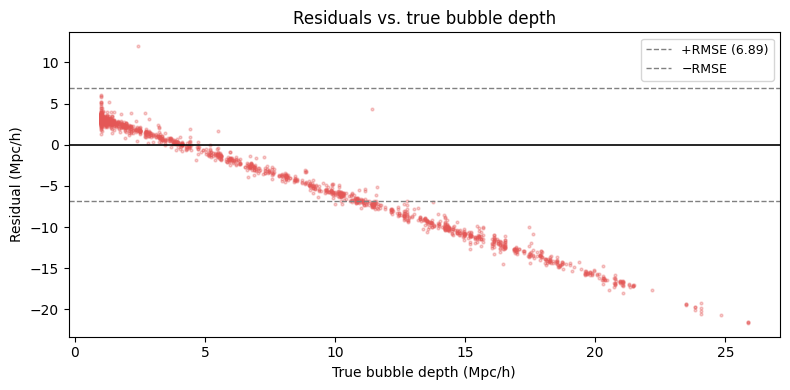

In [5]:
res = y_pred - y_true
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_true, res, s=4, alpha=0.3, color='#E45756', rasterized=True)
ax.axhline(0,     color='black', linewidth=1.2)
ax.axhline( rmse, color='gray',  linewidth=1, linestyle='--', label=f'+RMSE ({rmse:.2f})')
ax.axhline(-rmse, color='gray',  linewidth=1, linestyle='--', label=f'−RMSE')
ax.set_xlabel('True bubble depth (Mpc/h)')
ax.set_ylabel('Residual (Mpc/h)')
ax.set_title('Residuals vs. true bubble depth')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. CDF comparison

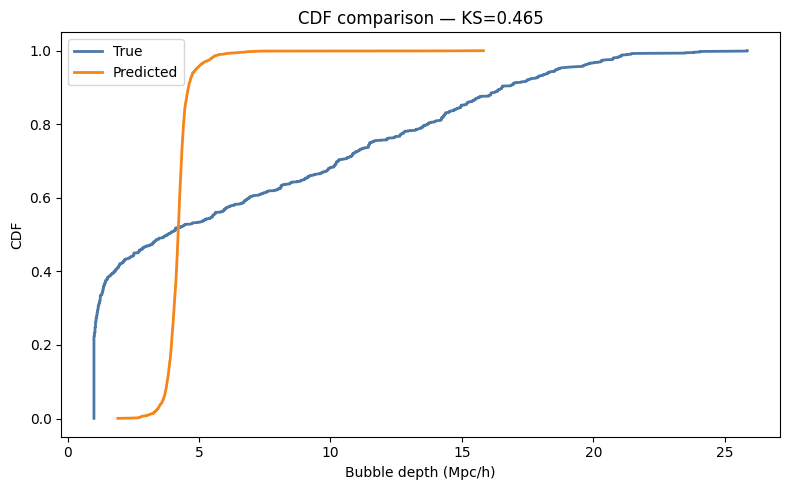

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for arr, label, color in [(y_true, 'True', '#4C78A8'), (y_pred, 'Predicted', '#F58518')]:
    s = np.sort(arr)
    cdf = np.arange(1, len(s) + 1) / len(s)
    ax.plot(s, cdf, color=color, label=label, linewidth=2)
ax.set_xlabel('Bubble depth (Mpc/h)')
ax.set_ylabel('CDF')
ax.set_title(f'CDF comparison — KS={ks:.3f}')
ax.legend()
fig.tight_layout()
plt.show()

## 6. Per-redshift breakdown

(One panel per redshift — useful once Anson provides data at multiple redshifts.)

In [7]:
# Summary statistics for the multi-ray RT-cube MFP targets
print(f"=== Target distribution (RT-cube multi-ray MFP) ===")
print(f"  zeros (neutral halos) : {(y_true == 0).mean()*100:.1f}%")
nz = y_true[y_true > 0]
print(f"  non-zero  count       : {len(nz)}")
print(f"  non-zero  median      : {np.median(nz):.2f} Mpc/h")
print(f"  non-zero  mean        : {nz.mean():.2f} Mpc/h")
print(f"  non-zero  max         : {nz.max():.2f} Mpc/h")
print()
print(f"=== Prediction statistics ===")
nz_p = y_pred[y_true > 0]
print(f"  predicted median (non-zero true) : {np.median(nz_p):.2f} Mpc/h")
print(f"  predicted mean   (non-zero true) : {nz_p.mean():.2f} Mpc/h")

=== Target distribution (RT-cube multi-ray MFP) ===
  zeros (neutral halos) : 0.0%
  non-zero  count       : 2000
  non-zero  median      : 3.80 Mpc/h
  non-zero  mean        : 6.76 Mpc/h
  non-zero  max         : 25.86 Mpc/h

=== Prediction statistics ===
  predicted median (non-zero true) : 4.20 Mpc/h
  predicted mean   (non-zero true) : 4.22 Mpc/h


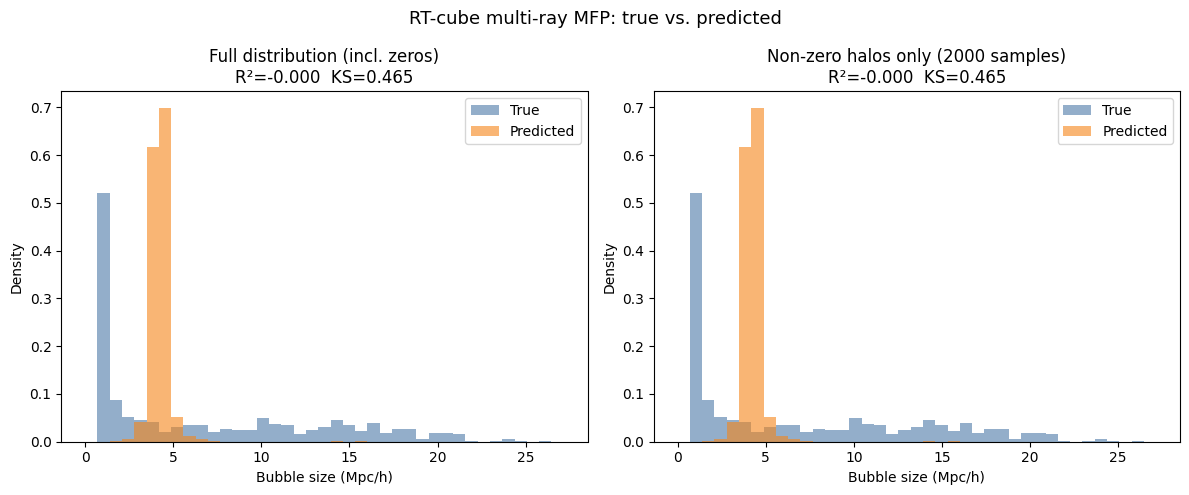

In [8]:
# Non-zero samples only — zoomed distribution
nz_mask = y_true > 0
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: full distribution (including zeros)
bins_full = np.linspace(0, max(y_true.max(), y_pred.max()) * 1.05, 40)
axes[0].hist(y_true, bins=bins_full, density=True, alpha=0.6, color='#4C78A8', label='True')
axes[0].hist(y_pred, bins=bins_full, density=True, alpha=0.6, color='#F58518', label='Predicted')
axes[0].set_title(f'Full distribution (incl. zeros)\nR²={r2:.3f}  KS={ks:.3f}')
axes[0].set_xlabel('Bubble size (Mpc/h)'); axes[0].set_ylabel('Density')
axes[0].legend()

# Right: non-zero only
yt_nz, yp_nz = y_true[nz_mask], y_pred[nz_mask]
ks_nz, _ = ks_2samp(yt_nz, yp_nz)
r2_nz = float(1 - np.var(yp_nz - yt_nz) / np.var(yt_nz))
bins_nz = np.linspace(0, yt_nz.max() * 1.05, 40)
axes[1].hist(yt_nz, bins=bins_nz, density=True, alpha=0.6, color='#4C78A8', label='True')
axes[1].hist(yp_nz, bins=bins_nz, density=True, alpha=0.6, color='#F58518', label='Predicted')
axes[1].set_title(f'Non-zero halos only ({nz_mask.sum()} samples)\nR²={r2_nz:.3f}  KS={ks_nz:.3f}')
axes[1].set_xlabel('Bubble size (Mpc/h)'); axes[1].set_ylabel('Density')
axes[1].legend()

fig.suptitle('RT-cube multi-ray MFP: true vs. predicted', fontsize=13)
fig.tight_layout()
plt.show()

**Note:** Targets are per-halo local MFPs computed from the RT cube (1 Mpc/h resolution) using 50 random rays per halo. Halos whose RT voxel has fion < 0.1 are assigned MFP = 0 (~43% of the test set). The non-zero halos have a median bubble size of ~14.6 Mpc/h at z=7.4985.

## 5. Per-redshift breakdown

(Shows one panel per redshift — useful once Anson provides data at multiple redshifts.)

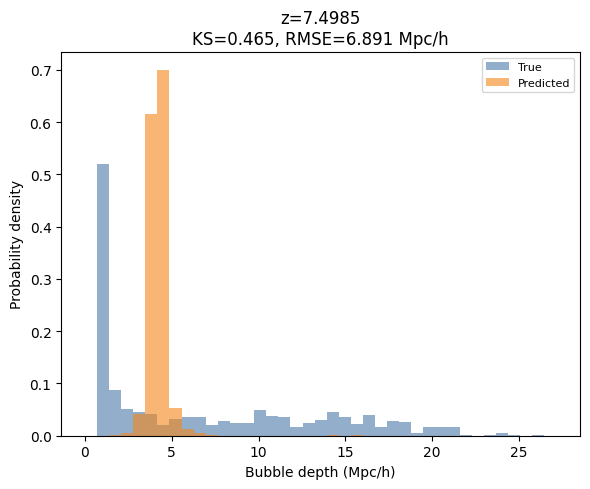

In [9]:
unique_z = np.unique(redshifts)
fig, axes = plt.subplots(1, len(unique_z), figsize=(6 * len(unique_z), 5), squeeze=False)

for ax, z in zip(axes[0], unique_z):
    mask = redshifts == z
    yt, yp = y_true[mask], y_pred[mask]
    ks_z, _ = ks_2samp(yt, yp)
    rmse_z = float(np.sqrt(np.mean((yp - yt) ** 2)))

    bins = np.linspace(0, max(yt.max(), yp.max()) * 1.05, 40)
    ax.hist(yt, bins=bins, density=True, alpha=0.6, color='#4C78A8', label='True')
    ax.hist(yp, bins=bins, density=True, alpha=0.6, color='#F58518', label='Predicted')
    ax.set_title(f'z={z:.4f}\nKS={ks_z:.3f}, RMSE={rmse_z:.3f} Mpc/h')
    ax.set_xlabel('Bubble depth (Mpc/h)')
    ax.set_ylabel('Probability density')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()